In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("NOTEBOOK 03: PROCESS RNA-SEQ COUNT DATA")
print("Goal: Merge 859 individual files into gene expression matrix")
print("=" * 70)

# Set random seed for reproducibility
np.random.seed(42)

# Paths
PROJECT_ROOT = Path.cwd().parent
RNASEQ_DIR = PROJECT_ROOT / 'data' / 'raw' / 'rnaseq'
COUNTS_DIR = RNASEQ_DIR / 'counts'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
RESULTS_DIR = PROJECT_ROOT / 'results'

print(f"\n📁 Directories:")
print(f"   Counts: {COUNTS_DIR}")
print(f"   Processed: {PROCESSED_DIR}")

# ============================================================
# STEP 1: Inspect Sample File Structure
# ============================================================
print("\n" + "=" * 70)
print("STEP 1: Understanding the Data Format")
print("=" * 70)

# Get list of all files
count_files = sorted(list(COUNTS_DIR.glob('*.tsv')))
print(f"\n✅ Found {len(count_files)} RNA-seq files")

# Load one file to understand structure
sample_file = count_files[0]
print(f"\n📄 Inspecting sample file: {sample_file.name}")

# Read first file
sample_df = pd.read_csv(sample_file, sep='\t', comment='#')
print(f"\n📊 File structure:")
print(f"   Shape: {sample_df.shape}")
print(f"   Columns: {sample_df.columns.tolist()}")
print(f"\n   First 10 rows:")
print(sample_df.head(10))

# Check for metadata rows
print(f"\n🔍 Checking for non-gene rows...")
# Common prefixes for non-gene rows
non_gene_prefixes = ['__', 'N_', 'ERCC']
non_gene_mask = sample_df.iloc[:, 0].str.startswith(tuple(non_gene_prefixes))
print(f"   Non-gene rows: {non_gene_mask.sum()}")
print(f"   Gene rows: {(~non_gene_mask).sum()}")

if non_gene_mask.any():
    print(f"\n   Non-gene rows found:")
    print(sample_df[non_gene_mask])

# ============================================================
# STEP 2: Load File Manifest with Patient IDs
# ============================================================
print("\n" + "=" * 70)
print("STEP 2: Loading File Manifest")
print("=" * 70)

# Load manifest (created in notebook 02)
manifest = pd.read_csv(RNASEQ_DIR / 'rnaseq_file_manifest.csv')
print(f"✅ Loaded manifest: {len(manifest)} files")
print(f"\n📋 Manifest columns: {manifest.columns.tolist()}")
print(f"\n   Sample of manifest:")
print(manifest.head())

# Create mapping: filename → patient ID
# The files are named by file_id, need to map to patient
filename_to_patient = {}
for _, row in manifest.iterrows():
    filename_to_patient[row['file_name']] = row['submitter_id']

print(f"\n✅ Created filename → patient ID mapping")
print(f"   Example: {list(filename_to_patient.items())[0]}")

NOTEBOOK 03: PROCESS RNA-SEQ COUNT DATA
Goal: Merge 859 individual files into gene expression matrix

📁 Directories:
   Counts: C:\Users\Abhinav\Mylo\myeloma-biomarker-project\data\raw\rnaseq\counts
   Processed: C:\Users\Abhinav\Mylo\myeloma-biomarker-project\data\processed

STEP 1: Understanding the Data Format

✅ Found 859 RNA-seq files

📄 Inspecting sample file: 000c5024-cee6-4ff6-bb79-312ccaf49572.rna_seq.augmented_star_gene_counts.tsv

📊 File structure:
   Shape: (60664, 9)
   Columns: ['gene_id', 'gene_name', 'gene_type', 'unstranded', 'stranded_first', 'stranded_second', 'tpm_unstranded', 'fpkm_unstranded', 'fpkm_uq_unstranded']

   First 10 rows:
              gene_id gene_name       gene_type  unstranded  stranded_first  \
0          N_unmapped       NaN             NaN     2151280         2151280   
1      N_multimapping       NaN             NaN    12948004        12948004   
2         N_noFeature       NaN             NaN    13093450        50504066   
3         N_ambiguou

In [3]:
# ============================================================
# STEP 3: Define Merging Strategy
# ============================================================
print("\n" + "=" * 70)
print("STEP 3: Planning the Merge Strategy")
print("=" * 70)

print("\n💡 LEARNING MOMENT: Which Count Type to Use?")
print("=" * 70)
print("""
We have multiple count types in each file:
1. unstranded       - Raw counts (most common for differential expression)
2. tpm_unstranded   - Transcripts Per Million (normalized for gene length)
3. fpkm_unstranded  - Fragments Per Kilobase Million (similar to TPM)

DECISION: We'll use 'unstranded' (raw counts) because:
- ✅ Standard for differential expression analysis
- ✅ Many tools (DESeq2-like) expect raw counts
- ✅ We can normalize later as needed
- ✅ Preserves original data

We'll also save TPM for certain analyses that need normalized values.
""")

print("\n📋 Merge Strategy:")
print("   1. Load each file")
print("   2. Extract gene_id and unstranded counts")
print("   3. Remove non-gene rows (N_*)")
print("   4. Map filename → patient ID")
print("   5. Build matrix: genes × patients")
print("   6. Quality control checks")

# ============================================================
# STEP 4: Create Gene Expression Matrix (MEMORY EFFICIENT)
# ============================================================
print("\n" + "=" * 70)
print("STEP 4: Merging All Files into Expression Matrix")
print("=" * 70)

print("\n⚠️  This will process 859 files (~3.6 GB)")
print("   Estimated time: 5-10 minutes")
print("   Memory usage: ~2 GB")
print("\n🔄 Starting merge process...\n")

# Initialize storage
count_data = {}  # Will store {patient_id: {gene_id: count}}
gene_list = None  # Will store ordered list of genes
patient_order = []  # Track order of patients

# Process each file
successful = 0
failed = 0
failed_files = []

for i, count_file in enumerate(tqdm(count_files, desc="Processing files")):
    try:
        # Read file
        df = pd.read_csv(count_file, sep='\t', comment='#')
        
        # Remove non-gene rows
        gene_mask = ~df['gene_id'].str.startswith(('N_', '__', 'ERCC'))
        df_genes = df[gene_mask].copy()
        
        # Clean gene IDs (remove version numbers for consistency)
        # ENSG00000000003.15 → ENSG00000000003
        df_genes['gene_id_clean'] = df_genes['gene_id'].str.split('.').str[0]
        
        # Get patient ID from manifest
        filename = count_file.name
        if filename in filename_to_patient:
            patient_id = filename_to_patient[filename]
        else:
            # If not in manifest, skip
            failed += 1
            failed_files.append(filename)
            continue
        
        # Store gene list from first file
        if gene_list is None:
            gene_list = df_genes['gene_id_clean'].tolist()
            print(f"   Gene list established: {len(gene_list)} genes")
        
        # Extract counts and store
        counts_dict = dict(zip(df_genes['gene_id_clean'], df_genes['unstranded']))
        count_data[patient_id] = counts_dict
        patient_order.append(patient_id)
        
        successful += 1
        
        # Progress update every 100 files
        if (i + 1) % 100 == 0:
            print(f"   Processed {i+1}/{len(count_files)} files...")
            
    except Exception as e:
        failed += 1
        failed_files.append((count_file.name, str(e)))

print(f"\n✅ Merge complete!")
print(f"   Successful: {successful}")
print(f"   Failed: {failed}")

if failed_files:
    print(f"\n⚠️  Failed files: {failed_files[:5]}")

# ============================================================
# STEP 5: Convert to DataFrame
# ============================================================
print("\n" + "=" * 70)
print("STEP 5: Creating Expression Matrix DataFrame")
print("=" * 70)

print("\n🔄 Building matrix...")

# Create matrix: genes (rows) × patients (columns)
expression_matrix = pd.DataFrame(count_data, index=gene_list)

# Reorder columns to match patient_order
expression_matrix = expression_matrix[patient_order]

print(f"✅ Expression matrix created!")
print(f"\n📊 Matrix dimensions:")
print(f"   Genes (rows): {expression_matrix.shape[0]:,}")
print(f"   Patients (columns): {expression_matrix.shape[1]:,}")
print(f"   Total values: {expression_matrix.shape[0] * expression_matrix.shape[1]:,}")

print(f"\n📋 Sample of expression matrix:")
print(expression_matrix.iloc[:10, :5])

# Check for missing values
missing_count = expression_matrix.isna().sum().sum()
print(f"\n🔍 Data quality:")
print(f"   Missing values: {missing_count}")
print(f"   Zero counts: {(expression_matrix == 0).sum().sum():,} ({(expression_matrix == 0).sum().sum() / expression_matrix.size * 100:.1f}%)")

# ============================================================
# STEP 6: Basic Quality Control
# ============================================================
print("\n" + "=" * 70)
print("STEP 6: Quality Control Checks")
print("=" * 70)

print("\n📊 Library Size Statistics (total counts per sample):")
library_sizes = expression_matrix.sum(axis=0)
print(f"   Mean: {library_sizes.mean():,.0f} counts")
print(f"   Median: {library_sizes.median():,.0f} counts")
print(f"   Min: {library_sizes.min():,.0f} counts")
print(f"   Max: {library_sizes.max():,.0f} counts")
print(f"   Std: {library_sizes.std():,.0f} counts")

# Check for outlier samples (very low library size)
threshold = library_sizes.median() * 0.5  # Less than 50% of median
outliers = library_sizes[library_sizes < threshold]
if len(outliers) > 0:
    print(f"\n⚠️  Warning: {len(outliers)} samples with low library size (<50% of median):")
    for patient, size in outliers.items():
        print(f"      {patient}: {size:,.0f} counts")
else:
    print(f"\n✅ All samples have reasonable library sizes")

print("\n📊 Gene Expression Statistics:")
print(f"   Genes with 0 counts in all samples: {(expression_matrix.sum(axis=1) == 0).sum()}")
print(f"   Genes expressed in >50% samples: {(expression_matrix > 0).sum(axis=1).gt(expression_matrix.shape[1]*0.5).sum()}")
print(f"   Genes expressed in >90% samples: {(expression_matrix > 0).sum(axis=1).gt(expression_matrix.shape[1]*0.9).sum()}")

# ============================================================
# STEP 7: Save Raw Expression Matrix
# ============================================================
print("\n" + "=" * 70)
print("STEP 7: Saving Expression Matrix")
print("=" * 70)

# Save as CSV (compressed)
output_path = PROCESSED_DIR / 'gene_expression_matrix_raw.csv.gz'
print(f"\n💾 Saving to: {output_path}")
print(f"   Format: CSV (gzip compressed)")

expression_matrix.to_csv(output_path, compression='gzip')

file_size_mb = output_path.stat().st_size / 1e6
print(f"✅ Saved successfully!")
print(f"   File size: {file_size_mb:.1f} MB")

# Also save patient list
patient_list_path = PROCESSED_DIR / 'rnaseq_patient_list.txt'
with open(patient_list_path, 'w') as f:
    for patient in patient_order:
        f.write(f"{patient}\n")
print(f"✅ Patient list saved: {patient_list_path}")

print("\n" + "=" * 70)
print("✅ NOTEBOOK 03 COMPLETE!")
print("=" * 70)
print(f"\n📊 Summary:")
print(f"   ✅ Processed {successful} RNA-seq files")
print(f"   ✅ Created expression matrix: {expression_matrix.shape[0]:,} genes × {expression_matrix.shape[1]} patients")
print(f"   ✅ Saved compressed matrix: {file_size_mb:.1f} MB")
print(f"   ✅ Ready for analysis!")

print(f"\n🚀 Next Steps:")
print(f"   1. Notebook 04: Data normalization and filtering")
print(f"   2. Notebook 04: Differential expression analysis")
print(f"   3. Quality control visualizations")



STEP 3: Planning the Merge Strategy

💡 LEARNING MOMENT: Which Count Type to Use?

We have multiple count types in each file:
1. unstranded       - Raw counts (most common for differential expression)
2. tpm_unstranded   - Transcripts Per Million (normalized for gene length)
3. fpkm_unstranded  - Fragments Per Kilobase Million (similar to TPM)

DECISION: We'll use 'unstranded' (raw counts) because:
- ✅ Standard for differential expression analysis
- ✅ Many tools (DESeq2-like) expect raw counts
- ✅ We can normalize later as needed
- ✅ Preserves original data

We'll also save TPM for certain analyses that need normalized values.


📋 Merge Strategy:
   1. Load each file
   2. Extract gene_id and unstranded counts
   3. Remove non-gene rows (N_*)
   4. Map filename → patient ID
   5. Build matrix: genes × patients
   6. Quality control checks

STEP 4: Merging All Files into Expression Matrix

⚠️  This will process 859 files (~3.6 GB)
   Estimated time: 5-10 minutes
   Memory usage: ~2 GB



Processing files:   0%|          | 2/859 [00:00<02:27,  5.80it/s]

   Gene list established: 60660 genes


Processing files:  12%|█▏        | 100/859 [00:19<02:33,  4.94it/s]

   Processed 100/859 files...


...

   Processed 700/859 files...


Processing files:  93%|█████████▎| 800/859 [02:41<00:12,  4.84it/s]

   Processed 800/859 files...


Processing files: 100%|██████████| 859/859 [02:54<00:00,  4.93it/s]



✅ Merge complete!
   Successful: 859
   Failed: 0

STEP 5: Creating Expression Matrix DataFrame

🔄 Building matrix...
✅ Expression matrix created!

📊 Matrix dimensions:
   Genes (rows): 60,660
   Patients (columns): 859
   Total values: 52,106,940

📋 Sample of expression matrix:
                 MMRF_1817  MMRF_1950  MMRF_1290  MMRF_2694  MMRF_2564
ENSG00000000003       2101        280          2        839        150
ENSG00000000005          0          0          0          0          0
ENSG00000000419       1950       2591        877       1511       2279
ENSG00000000457       1676        680        911        627        838
ENSG00000000460        610        253        222        258        432
ENSG00000000938         45          8         22        100         17
ENSG00000000971        273          4          1       6069         20
ENSG00000001036        841       1852        343       1157       1889
ENSG00000001084       1174       1214        929        568       1018
ENSG00000


STEP 8: Quality Control Visualizations

📊 Creating Figure 1: Library Size Distribution...
✅ Saved: C:\Users\Abhinav\Mylo\myeloma-biomarker-project\results\figures\rnaseq_qc_library_sizes.png


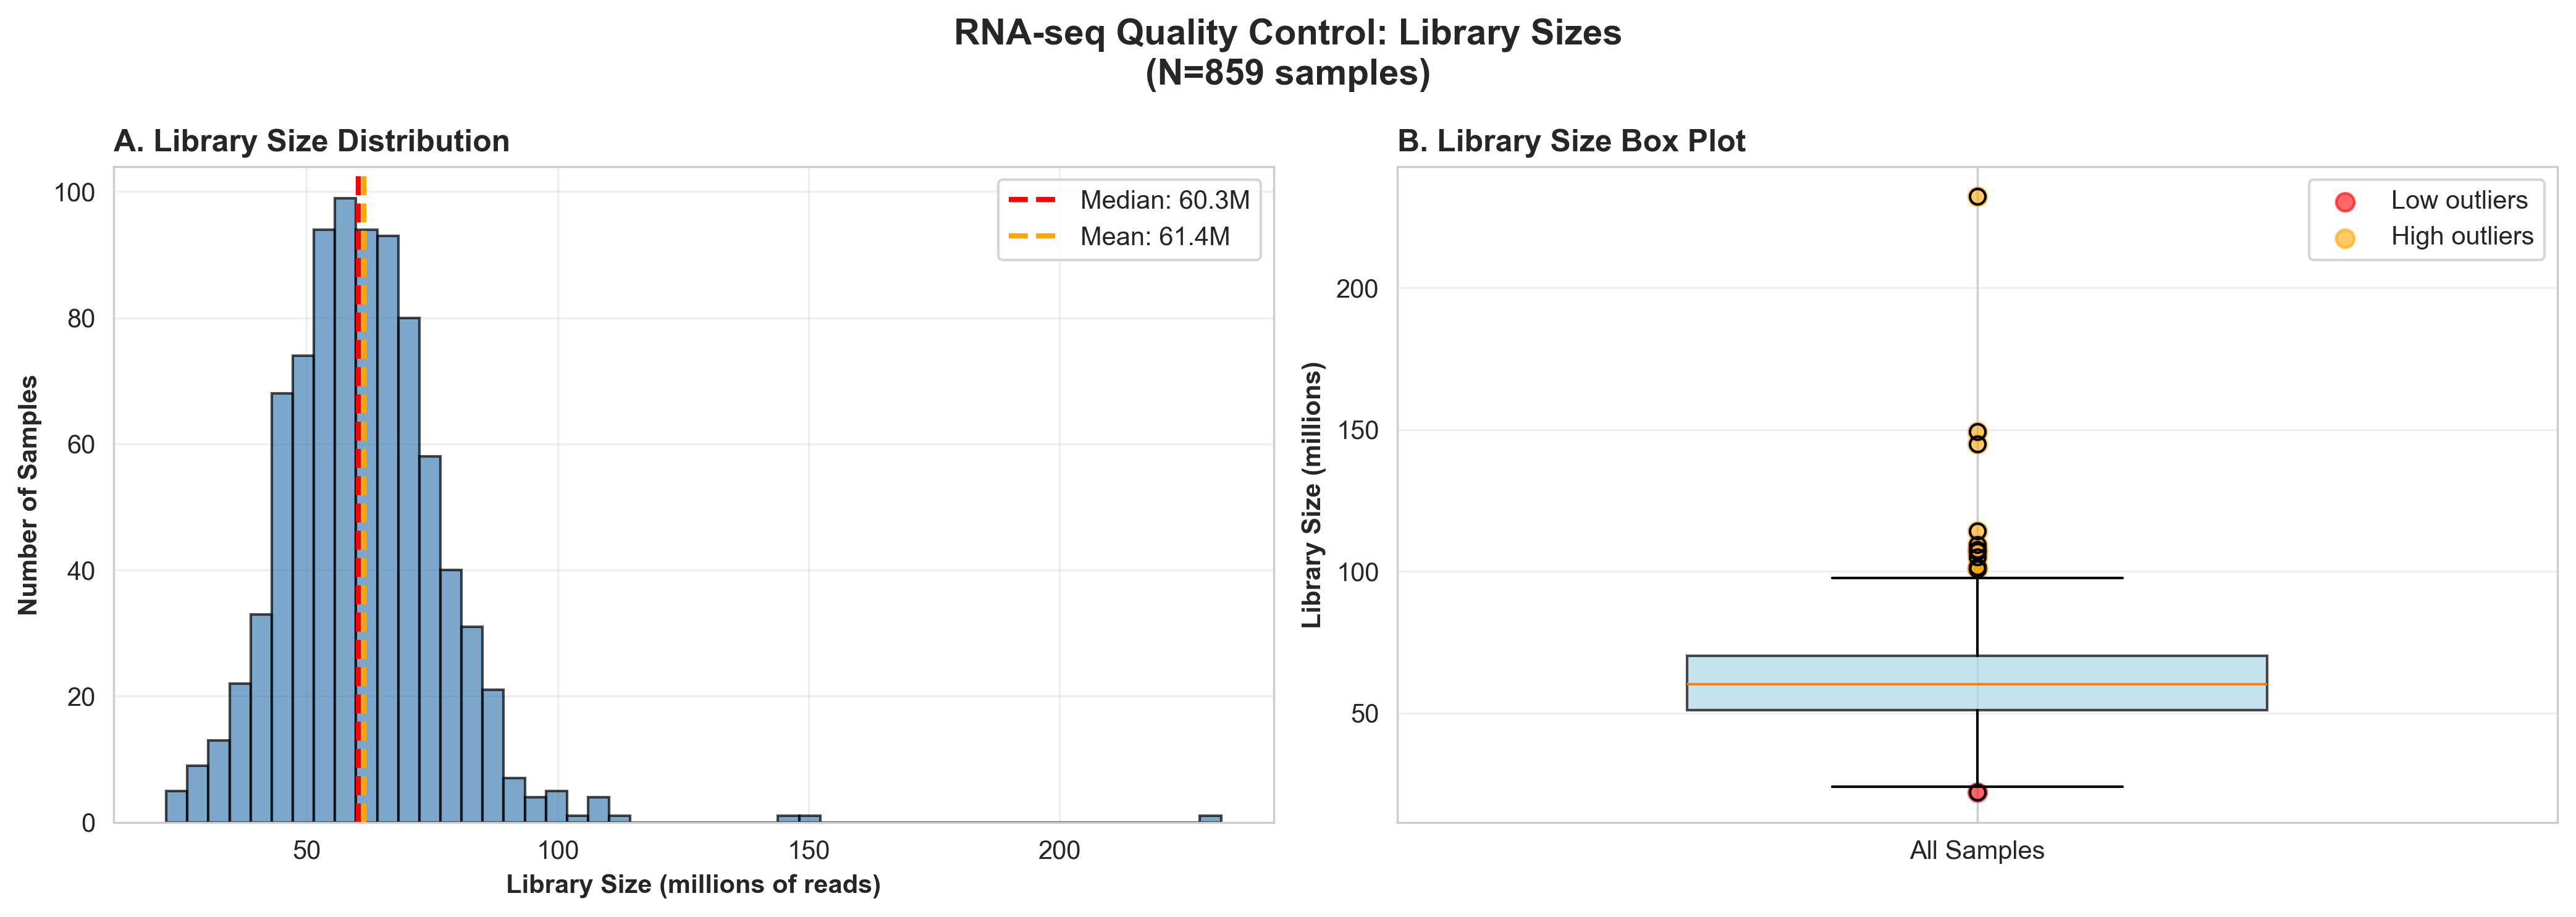


   Identified outliers:
      Low outliers (<22.0M): 1
      High outliers (>99.3M): 13

📊 Creating Figure 2: Gene Expression Distribution...
✅ Saved: C:\Users\Abhinav\Mylo\myeloma-biomarker-project\results\figures\rnaseq_qc_gene_expression.png


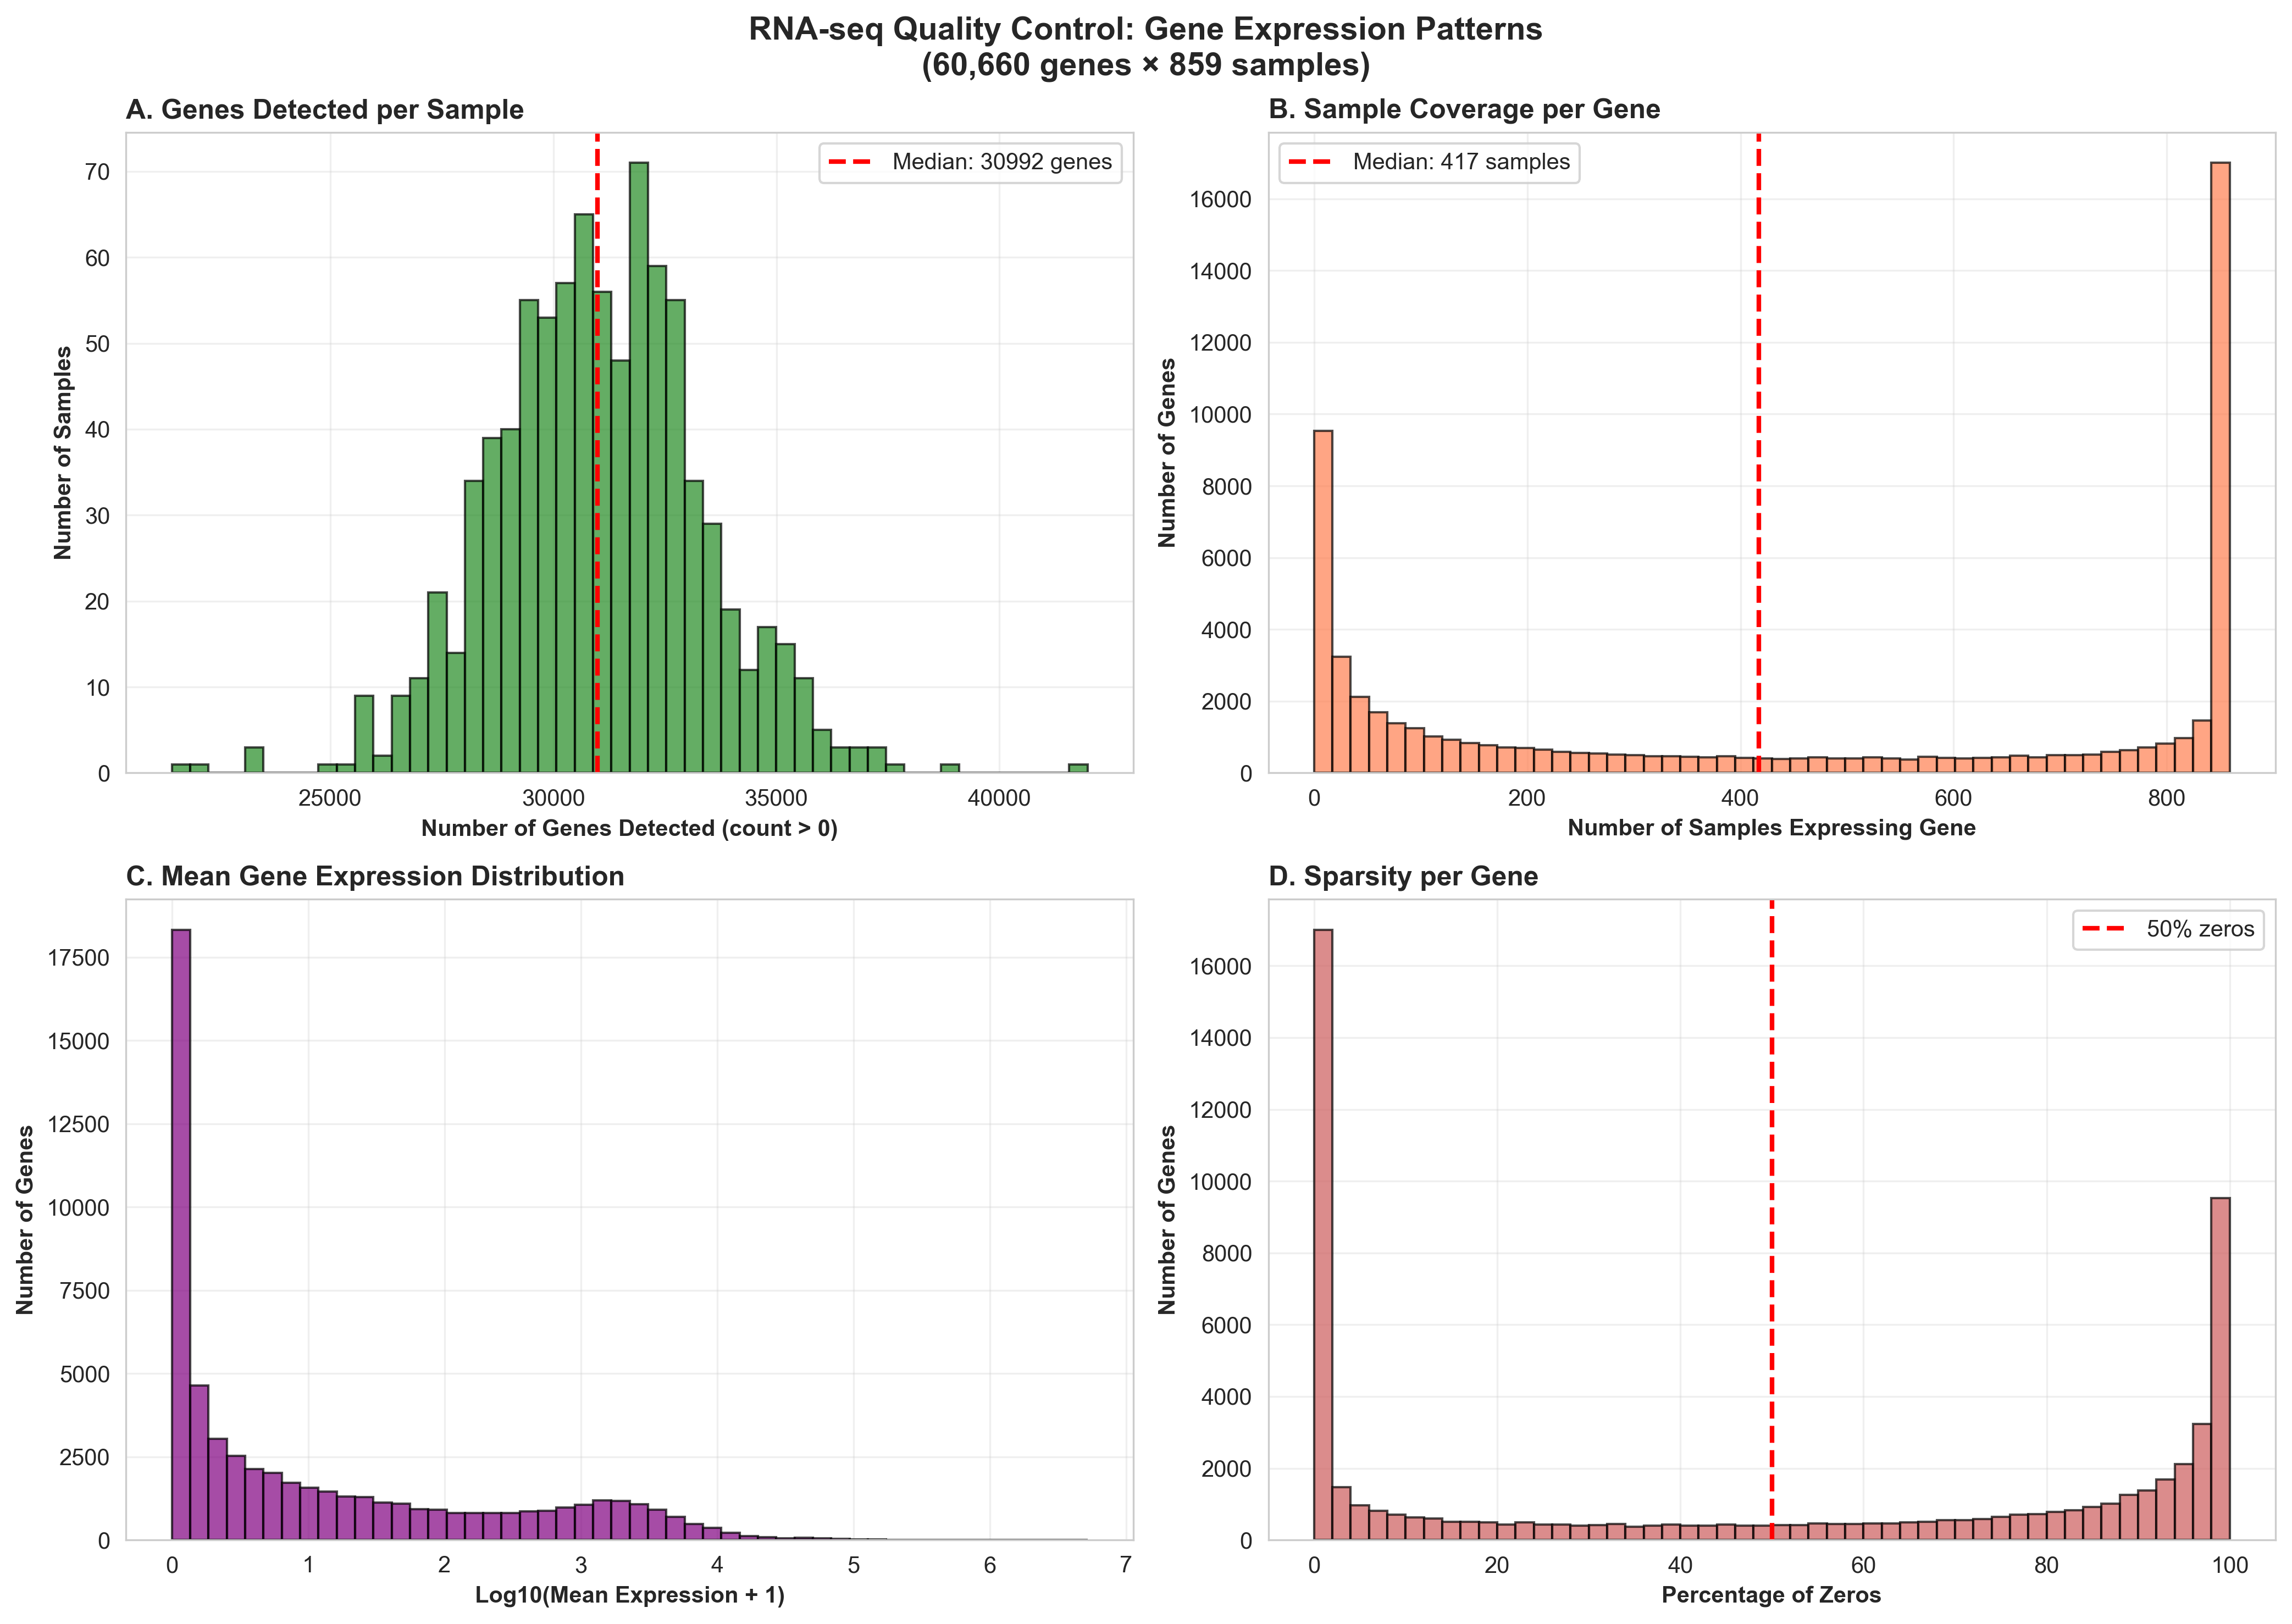


📊 Creating Figure 3: PCA Analysis...
   (This may take 1-2 minutes for 60K genes...)
   Using 42,699 genes for PCA
✅ Saved: C:\Users\Abhinav\Mylo\myeloma-biomarker-project\results\figures\rnaseq_qc_pca.png


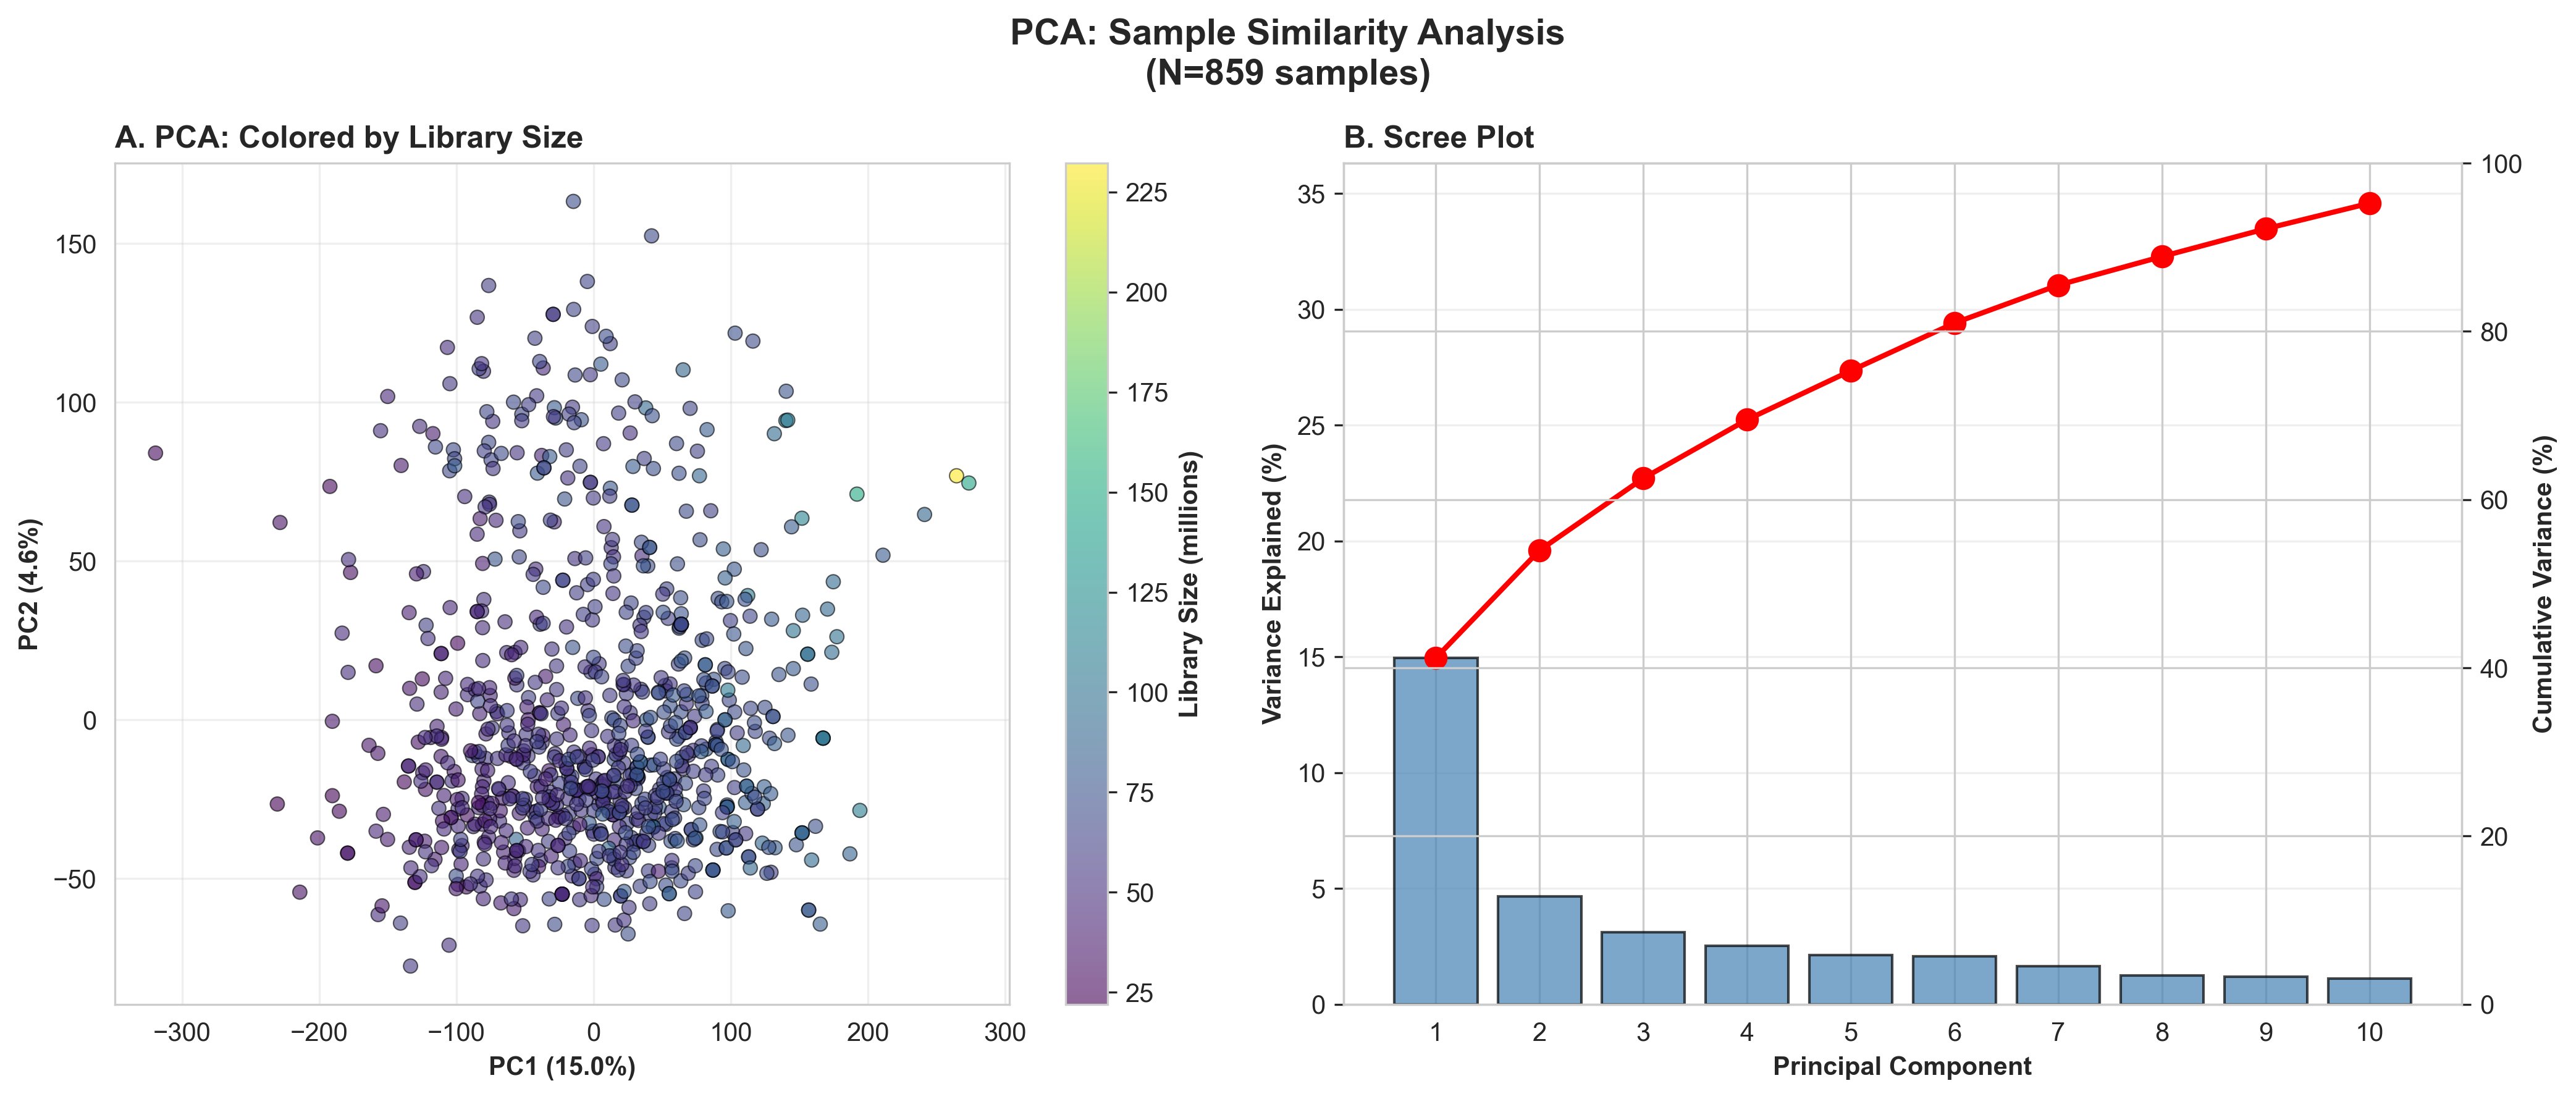


   Variance explained by first 3 PCs: 22.7%

✅ QUALITY CONTROL VISUALIZATIONS COMPLETE!

📊 Created 3 QC figure panels:
   1. Library size distribution
   2. Gene expression patterns
   3. PCA sample similarity


In [5]:
# ============================================================
# STEP 8: Quality Control Visualizations
# ============================================================
print("\n" + "=" * 70)
print("STEP 8: Quality Control Visualizations")
print("=" * 70)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300

# Create figure directory
FIGURES_DIR = RESULTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# FIGURE 1: Library Size Distribution
# ============================================================
print("\n📊 Creating Figure 1: Library Size Distribution...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: Histogram
ax1 = axes[0]
library_sizes = expression_matrix.sum(axis=0)

ax1.hist(library_sizes / 1e6, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(library_sizes.median() / 1e6, color='red', linestyle='--', linewidth=2, 
            label=f'Median: {library_sizes.median()/1e6:.1f}M')
ax1.axvline(library_sizes.mean() / 1e6, color='orange', linestyle='--', linewidth=2,
            label=f'Mean: {library_sizes.mean()/1e6:.1f}M')

ax1.set_xlabel('Library Size (millions of reads)', fontweight='bold')
ax1.set_ylabel('Number of Samples', fontweight='bold')
ax1.set_title('A. Library Size Distribution', fontweight='bold', loc='left')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel B: Box plot
ax2 = axes[1]
box_data = library_sizes / 1e6

bp = ax2.boxplot([box_data], vert=True, patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)

# Highlight outliers
Q1 = box_data.quantile(0.25)
Q3 = box_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_low = box_data[box_data < lower_bound]
outliers_high = box_data[box_data > upper_bound]

ax2.scatter([1] * len(outliers_low), outliers_low, color='red', s=50, alpha=0.6, label='Low outliers')
ax2.scatter([1] * len(outliers_high), outliers_high, color='orange', s=50, alpha=0.6, label='High outliers')

ax2.set_ylabel('Library Size (millions)', fontweight='bold')
ax2.set_title('B. Library Size Box Plot', fontweight='bold', loc='left')
ax2.set_xticklabels(['All Samples'])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('RNA-seq Quality Control: Library Sizes\n(N=859 samples)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()

fig_path = FIGURES_DIR / 'rnaseq_qc_library_sizes.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {fig_path}")
plt.show()

print(f"\n   Identified outliers:")
print(f"      Low outliers (<{lower_bound:.1f}M): {len(outliers_low)}")
print(f"      High outliers (>{upper_bound:.1f}M): {len(outliers_high)}")

# ============================================================
# FIGURE 2: Gene Expression Distribution
# ============================================================
print("\n📊 Creating Figure 2: Gene Expression Distribution...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Genes detected per sample
ax1 = axes[0, 0]
genes_detected = (expression_matrix > 0).sum(axis=0)

ax1.hist(genes_detected, bins=50, color='forestgreen', alpha=0.7, edgecolor='black')
ax1.axvline(genes_detected.median(), color='red', linestyle='--', linewidth=2,
            label=f'Median: {genes_detected.median():.0f} genes')
ax1.set_xlabel('Number of Genes Detected (count > 0)', fontweight='bold')
ax1.set_ylabel('Number of Samples', fontweight='bold')
ax1.set_title('A. Genes Detected per Sample', fontweight='bold', loc='left')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel B: Sample detection per gene
ax2 = axes[0, 1]
samples_detected = (expression_matrix > 0).sum(axis=1)

ax2.hist(samples_detected, bins=50, color='coral', alpha=0.7, edgecolor='black')
ax2.axvline(samples_detected.median(), color='red', linestyle='--', linewidth=2,
            label=f'Median: {samples_detected.median():.0f} samples')
ax2.set_xlabel('Number of Samples Expressing Gene', fontweight='bold')
ax2.set_ylabel('Number of Genes', fontweight='bold')
ax2.set_title('B. Sample Coverage per Gene', fontweight='bold', loc='left')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Panel C: Mean expression distribution (log scale)
ax3 = axes[1, 0]
mean_expression = expression_matrix.mean(axis=1)
mean_expression_nonzero = mean_expression[mean_expression > 0]

ax3.hist(np.log10(mean_expression_nonzero + 1), bins=50, color='purple', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Log10(Mean Expression + 1)', fontweight='bold')
ax3.set_ylabel('Number of Genes', fontweight='bold')
ax3.set_title('C. Mean Gene Expression Distribution', fontweight='bold', loc='left')
ax3.grid(True, alpha=0.3)

# Panel D: Percentage of zeros per gene
ax4 = axes[1, 1]
zero_percentage = (expression_matrix == 0).sum(axis=1) / expression_matrix.shape[1] * 100

ax4.hist(zero_percentage, bins=50, color='indianred', alpha=0.7, edgecolor='black')
ax4.axvline(50, color='red', linestyle='--', linewidth=2, label='50% zeros')
ax4.set_xlabel('Percentage of Zeros', fontweight='bold')
ax4.set_ylabel('Number of Genes', fontweight='bold')
ax4.set_title('D. Sparsity per Gene', fontweight='bold', loc='left')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle('RNA-seq Quality Control: Gene Expression Patterns\n(60,660 genes × 859 samples)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()

fig_path = FIGURES_DIR / 'rnaseq_qc_gene_expression.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {fig_path}")
plt.show()

# ============================================================
# FIGURE 3: PCA - Sample Similarity
# ============================================================
print("\n📊 Creating Figure 3: PCA Analysis...")
print("   (This may take 1-2 minutes for 60K genes...)")

# Filter to expressed genes only (speed up PCA)
expressed_genes_mask = (expression_matrix > 0).sum(axis=1) > expression_matrix.shape[1] * 0.1  # Expressed in >10% samples
expression_filtered = expression_matrix[expressed_genes_mask]

print(f"   Using {expressed_genes_mask.sum():,} genes for PCA")

# Log transform (add pseudocount)
expression_log = np.log2(expression_filtered + 1)

# Standardize
scaler = StandardScaler()
expression_scaled = scaler.fit_transform(expression_log.T)  # Transpose: samples as rows

# PCA
pca = PCA(n_components=10)
pca_result = pca.fit_transform(expression_scaled)

# Create DataFrame
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'PC3': pca_result[:, 2],
    'patient_id': expression_matrix.columns,
    'library_size': library_sizes.values / 1e6
})

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: PC1 vs PC2 colored by library size
ax1 = axes[0]
scatter = ax1.scatter(pca_df['PC1'], pca_df['PC2'], 
                     c=pca_df['library_size'], cmap='viridis',
                     s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontweight='bold')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontweight='bold')
ax1.set_title('A. PCA: Colored by Library Size', fontweight='bold', loc='left')
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Library Size (millions)', fontweight='bold')
ax1.grid(True, alpha=0.3)

# Panel B: Scree plot
ax2 = axes[1]
variance_explained = pca.explained_variance_ratio_ * 100
ax2.bar(range(1, 11), variance_explained, color='steelblue', alpha=0.7, edgecolor='black')
ax2.plot(range(1, 11), np.cumsum(variance_explained), 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Principal Component', fontweight='bold')
ax2.set_ylabel('Variance Explained (%)', fontweight='bold')
ax2.set_title('B. Scree Plot', fontweight='bold', loc='left')
ax2.set_xticks(range(1, 11))
ax2.grid(True, alpha=0.3, axis='y')

# Add cumulative line legend
ax2_twin = ax2.twinx()
ax2_twin.set_ylabel('Cumulative Variance (%)', fontweight='bold')
ax2_twin.set_ylim([0, 100])

plt.suptitle('PCA: Sample Similarity Analysis\n(N=859 samples)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()

fig_path = FIGURES_DIR / 'rnaseq_qc_pca.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {fig_path}")
plt.show()

print(f"\n   Variance explained by first 3 PCs: {pca.explained_variance_ratio_[:3].sum()*100:.1f}%")

print("\n" + "=" * 70)
print("✅ QUALITY CONTROL VISUALIZATIONS COMPLETE!")
print("=" * 70)
print(f"\n📊 Created 3 QC figure panels:")
print(f"   1. Library size distribution")
print(f"   2. Gene expression patterns")
print(f"   3. PCA sample similarity")

In [7]:
# ============================================================
# STEP 9: Filter Low-Expressed Genes
# ============================================================
print("\n" + "=" * 70)
print("STEP 9: Filtering Low-Expressed Genes")
print("=" * 70)

print("\n💡 FILTERING STRATEGY:")
print("=" * 70)
print("""
Why filter?
- Genes with very low counts across all samples add noise
- Statistical tests are less reliable with low counts
- Multiple testing: fewer tests = more power

Our criteria:
- Keep genes expressed (count > 0) in at least 50% of samples
- This balances sensitivity (keeping real genes) and specificity (removing noise)
""")

# Apply filter
min_samples = expression_matrix.shape[1] * 0.5  # 50% of samples
genes_to_keep = (expression_matrix > 0).sum(axis=1) >= min_samples

expression_filtered = expression_matrix[genes_to_keep].copy()

print(f"\n📊 Filtering Results:")
print(f"   Original genes: {expression_matrix.shape[0]:,}")
print(f"   Genes passing filter: {expression_filtered.shape[0]:,}")
print(f"   Genes removed: {expression_matrix.shape[0] - expression_filtered.shape[0]:,}")
print(f"   Retention rate: {expression_filtered.shape[0]/expression_matrix.shape[0]*100:.1f}%")

# ============================================================
# STEP 10: Normalize (TPM-like normalization)
# ============================================================
print("\n" + "=" * 70)
print("STEP 10: Count Normalization")
print("=" * 70)

print("\n💡 NORMALIZATION STRATEGY:")
print("=" * 70)
print("""
Why normalize?
- Different samples have different library sizes (22M vs 232M reads)
- Can't compare raw counts directly between samples
- Need to account for sequencing depth

Methods:
1. CPM (Counts Per Million) - simple, we'll use this
2. TPM (Transcripts Per Million) - accounts for gene length
3. DESeq2 size factors - for differential expression (later)

We'll create multiple normalized versions for different analyses.
""")

# Calculate library sizes for filtered matrix
library_sizes_filtered = expression_filtered.sum(axis=0)

# Method 1: Counts Per Million (CPM)
cpm = (expression_filtered / library_sizes_filtered * 1e6)

print(f"✅ CPM normalization complete")
print(f"   Example: Sample with 60M reads")
print(f"   Raw count of 600 → CPM of {600/60e6*1e6:.1f}")

# Method 2: Log2(CPM + 1) for visualization and clustering
log2_cpm = np.log2(cpm + 1)

print(f"✅ Log2(CPM+1) transformation complete")
print(f"   Used for: PCA, clustering, heatmaps")
print(f"   Stabilizes variance, makes distributions more normal")

# ============================================================
# STEP 11: Save Filtered & Normalized Data
# ============================================================
print("\n" + "=" * 70)
print("STEP 11: Saving Processed Data")
print("=" * 70)

# Save filtered raw counts (for differential expression)
filtered_raw_path = PROCESSED_DIR / 'gene_expression_filtered_raw.csv.gz'
expression_filtered.to_csv(filtered_raw_path, compression='gzip')
print(f"✅ Saved filtered raw counts: {filtered_raw_path}")
print(f"   Size: {filtered_raw_path.stat().st_size/1e6:.1f} MB")

# Save CPM normalized
cpm_path = PROCESSED_DIR / 'gene_expression_cpm.csv.gz'
cpm.to_csv(cpm_path, compression='gzip')
print(f"✅ Saved CPM normalized: {cpm_path}")

# Save log2 transformed
log2_path = PROCESSED_DIR / 'gene_expression_log2cpm.csv.gz'
log2_cpm.to_csv(log2_path, compression='gzip')
print(f"✅ Saved log2(CPM+1): {log2_path}")

# Create summary statistics
summary_stats = pd.DataFrame({
    'total_samples': [expression_filtered.shape[1]],
    'total_genes': [expression_filtered.shape[0]],
    'genes_original': [expression_matrix.shape[0]],
    'genes_filtered_out': [expression_matrix.shape[0] - expression_filtered.shape[0]],
    'median_library_size': [library_sizes_filtered.median()],
    'mean_library_size': [library_sizes_filtered.mean()],
    'min_library_size': [library_sizes_filtered.min()],
    'max_library_size': [library_sizes_filtered.max()]
})

stats_path = PROCESSED_DIR / 'processing_summary_stats.csv'
summary_stats.to_csv(stats_path, index=False)
print(f"✅ Saved processing summary: {stats_path}")

print("\n" + "=" * 70)
print("✅ DATA PROCESSING COMPLETE!")
print("=" * 70)
print(f"\n📊 Final Dataset:")
print(f"   Samples: {expression_filtered.shape[1]}")
print(f"   Genes: {expression_filtered.shape[0]:,}")
print(f"   Data versions created:")
print(f"      1. Raw counts (for differential expression)")
print(f"      2. CPM (for comparisons)")
print(f"      3. Log2(CPM+1) (for visualization)")

print(f"\n🚀 Ready for:")
print(f"   ✅ Differential expression analysis")
print(f"   ✅ Survival-gene correlations")
print(f"   ✅ Machine learning models")
print(f"   ✅ Pathway enrichment")

print(f"\n📝 Next notebook: 04_differential_expression_analysis.ipynb")


STEP 9: Filtering Low-Expressed Genes

💡 FILTERING STRATEGY:

Why filter?
- Genes with very low counts across all samples add noise
- Statistical tests are less reliable with low counts
- Multiple testing: fewer tests = more power

Our criteria:
- Keep genes expressed (count > 0) in at least 50% of samples
- This balances sensitivity (keeping real genes) and specificity (removing noise)


📊 Filtering Results:
   Original genes: 60,660
   Genes passing filter: 30,018
   Genes removed: 30,642
   Retention rate: 49.5%

STEP 10: Count Normalization

💡 NORMALIZATION STRATEGY:

Why normalize?
- Different samples have different library sizes (22M vs 232M reads)
- Can't compare raw counts directly between samples
- Need to account for sequencing depth

Methods:
1. CPM (Counts Per Million) - simple, we'll use this
2. TPM (Transcripts Per Million) - accounts for gene length
3. DESeq2 size factors - for differential expression (later)

We'll create multiple normalized versions for different anal